# 05 · ANALYZE — Q2: El Niño (ONI) ↔ precio Bangkok
Serie mensual ene-2011 a ago-2026 (188 meses). Errores HAC (Newey-West, 12 rezagos).

In [1]:
import sys, warnings, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings('ignore')
import pandas as pd, numpy as np
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 30)
from IPython.display import Image, display
from src.analysis import q2
r = q2()
print('ADF p-values:', {k: round(v,3) for k,v in r['adf'].items()})
print('Lag óptimo CCF:', r['lag_optimo'], 'meses; r =', round(r['ccf_lag_optimo'],3))

ADF p-values: {'precio_usd_ton': 0.07, 'oni_anom': 0.037, 'dlog_precio': 0.0}
Lag óptimo CCF: 7 meses; r = -0.385


In [2]:
display(r['ccf_df'].round(3))

,lag_meses,ccf_bruta,ccf_preblanqueada,banda_95,sig_bruta,sig_preblanqueada
0,0,-0.289,0.027,0.143,True,False
1,1,-0.313,-0.030,0.143,True,False
2,2,-0.331,0.013,0.143,True,False
3,3,-0.354,0.082,0.143,True,False
4,4,-0.373,-0.019,0.143,True,False
5,5,-0.383,-0.012,0.143,True,False
6,6,-0.383,-0.076,0.143,True,False
7,7,-0.385,0.044,0.143,True,False
8,8,-0.378,-0.038,0.143,True,False
9,9,-0.367,0.151,0.143,True,True


In [3]:
g = r['granger']
display(g.pivot(index='lag', columns='hipotesis', values='p_value').round(3))

hipotesis,ONI → precio (niveles),ONI → Δlog precio,precio → ONI (control)
lag,,,
1,0.278,0.873,0.239
2,0.351,0.933,0.640
3,0.166,0.541,0.784
4,0.367,0.668,0.663
5,0.485,0.618,0.653
6,0.612,0.757,0.615
7,0.652,0.923,0.792
8,0.841,0.937,0.703
9,0.862,0.794,0.158


In [4]:
display(pd.read_csv('../outputs/tables/q2_precio_por_episodio_enso.csv'))
display(r['tests_enso'])
print(open('../outputs/tables/q2_tukey_hsd.txt').read())

,ep,mean,median,std,count,rezago_meses
0,El Niño,1377.5,1390.0,289.5,51,0
1,La Niña,1621.2,1600.0,220.7,46,0
2,Neutro,1685.3,1600.0,323.3,91,0
3,El Niño,1323.8,1375.0,204.4,47,7
4,La Niña,1757.8,1715.0,284.8,46,7
5,Neutro,1630.5,1600.0,311.3,88,7


,rezago_meses,anova_F,anova_p,kruskal_H,kruskal_p,welch_t_nino_vs_nina,welch_p,dif_nino_menos_nina_usd,dif_HAC_p,dif_HAC_ic95,nino_vs_neutro_HAC_usd,nino_vs_neutro_HAC_p
0,0,18.5876,0.0,28.7207,0.0,-4.6890,0.0,-243.7447,0.0231,"[-454.0, -33.0]",-307.8567,0.0026
1,7,30.2552,0.0,47.6728,0.0,-8.4269,0.0,-433.9528,0.0003,"[-667.0, -201.0]",-306.6816,0.0003


   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1  group2  meandiff p-adj   lower    upper   reject
---------------------------------------------------------
El Niño La Niña  433.9528   0.0  296.4558 571.4498   True
El Niño  Neutro  306.6816   0.0  186.9093 426.4538   True
La Niña  Neutro -127.2712 0.036 -247.8891  -6.6534   True
---------------------------------------------------------


In [5]:
display(r['poly'].round(3))
print(r['mod_poly'].summary())

,lag,b_lineal_usd_por_1C,p_lineal,r2_lineal,b1_poly,b2_poly,p_b2,r2_poly,aic_lineal,aic_poly,oni_precio_minimo
0,0,-111.570,0.034,0.083,-77.473,-34.425,0.467,0.092,2687.182,2687.435,-1.125
1,1,-125.083,0.008,0.101,-89.859,-36.777,0.416,0.111,2670.159,2670.193,-1.222
2,2,-135.680,0.002,0.116,-111.480,-25.628,0.584,0.121,2653.756,2654.800,-2.175
3,3,-147.088,0.001,0.135,-145.916,-1.242,0.980,0.135,2636.465,2638.463,-58.765
4,4,-155.909,0.001,0.151,-177.362,22.631,0.652,0.154,2619.766,2621.000,3.919
5,5,-160.307,0.001,0.160,-197.750,39.388,0.436,0.170,2603.981,2603.642,2.510
6,6,-160.635,0.002,0.161,-207.124,48.893,0.331,0.178,2589.445,2587.833,2.118
7,7,-161.430,0.002,0.163,-219.240,60.851,0.211,0.188,2575.899,2572.300,1.801
8,8,-158.994,0.003,0.158,-225.831,70.370,0.123,0.192,2563.007,2557.534,1.605
9,9,-155.096,0.004,0.151,-230.482,79.203,0.059,0.195,2549.772,2542.313,1.455


                            OLS Regression Results                            
Dep. Variable:         precio_usd_ton   R-squared:                       0.188
Model:                            OLS   Adj. R-squared:                  0.179
Method:                 Least Squares   F-statistic:                     7.595
Date:                Wed, 07 Oct 2026   Prob (F-statistic):           0.000684
Time:                        17:25:40   Log-Likelihood:                -1283.1
No. Observations:                 181   AIC:                             2572.
Df Residuals:                     178   BIC:                             2582.
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept        1559.4378     69.332     

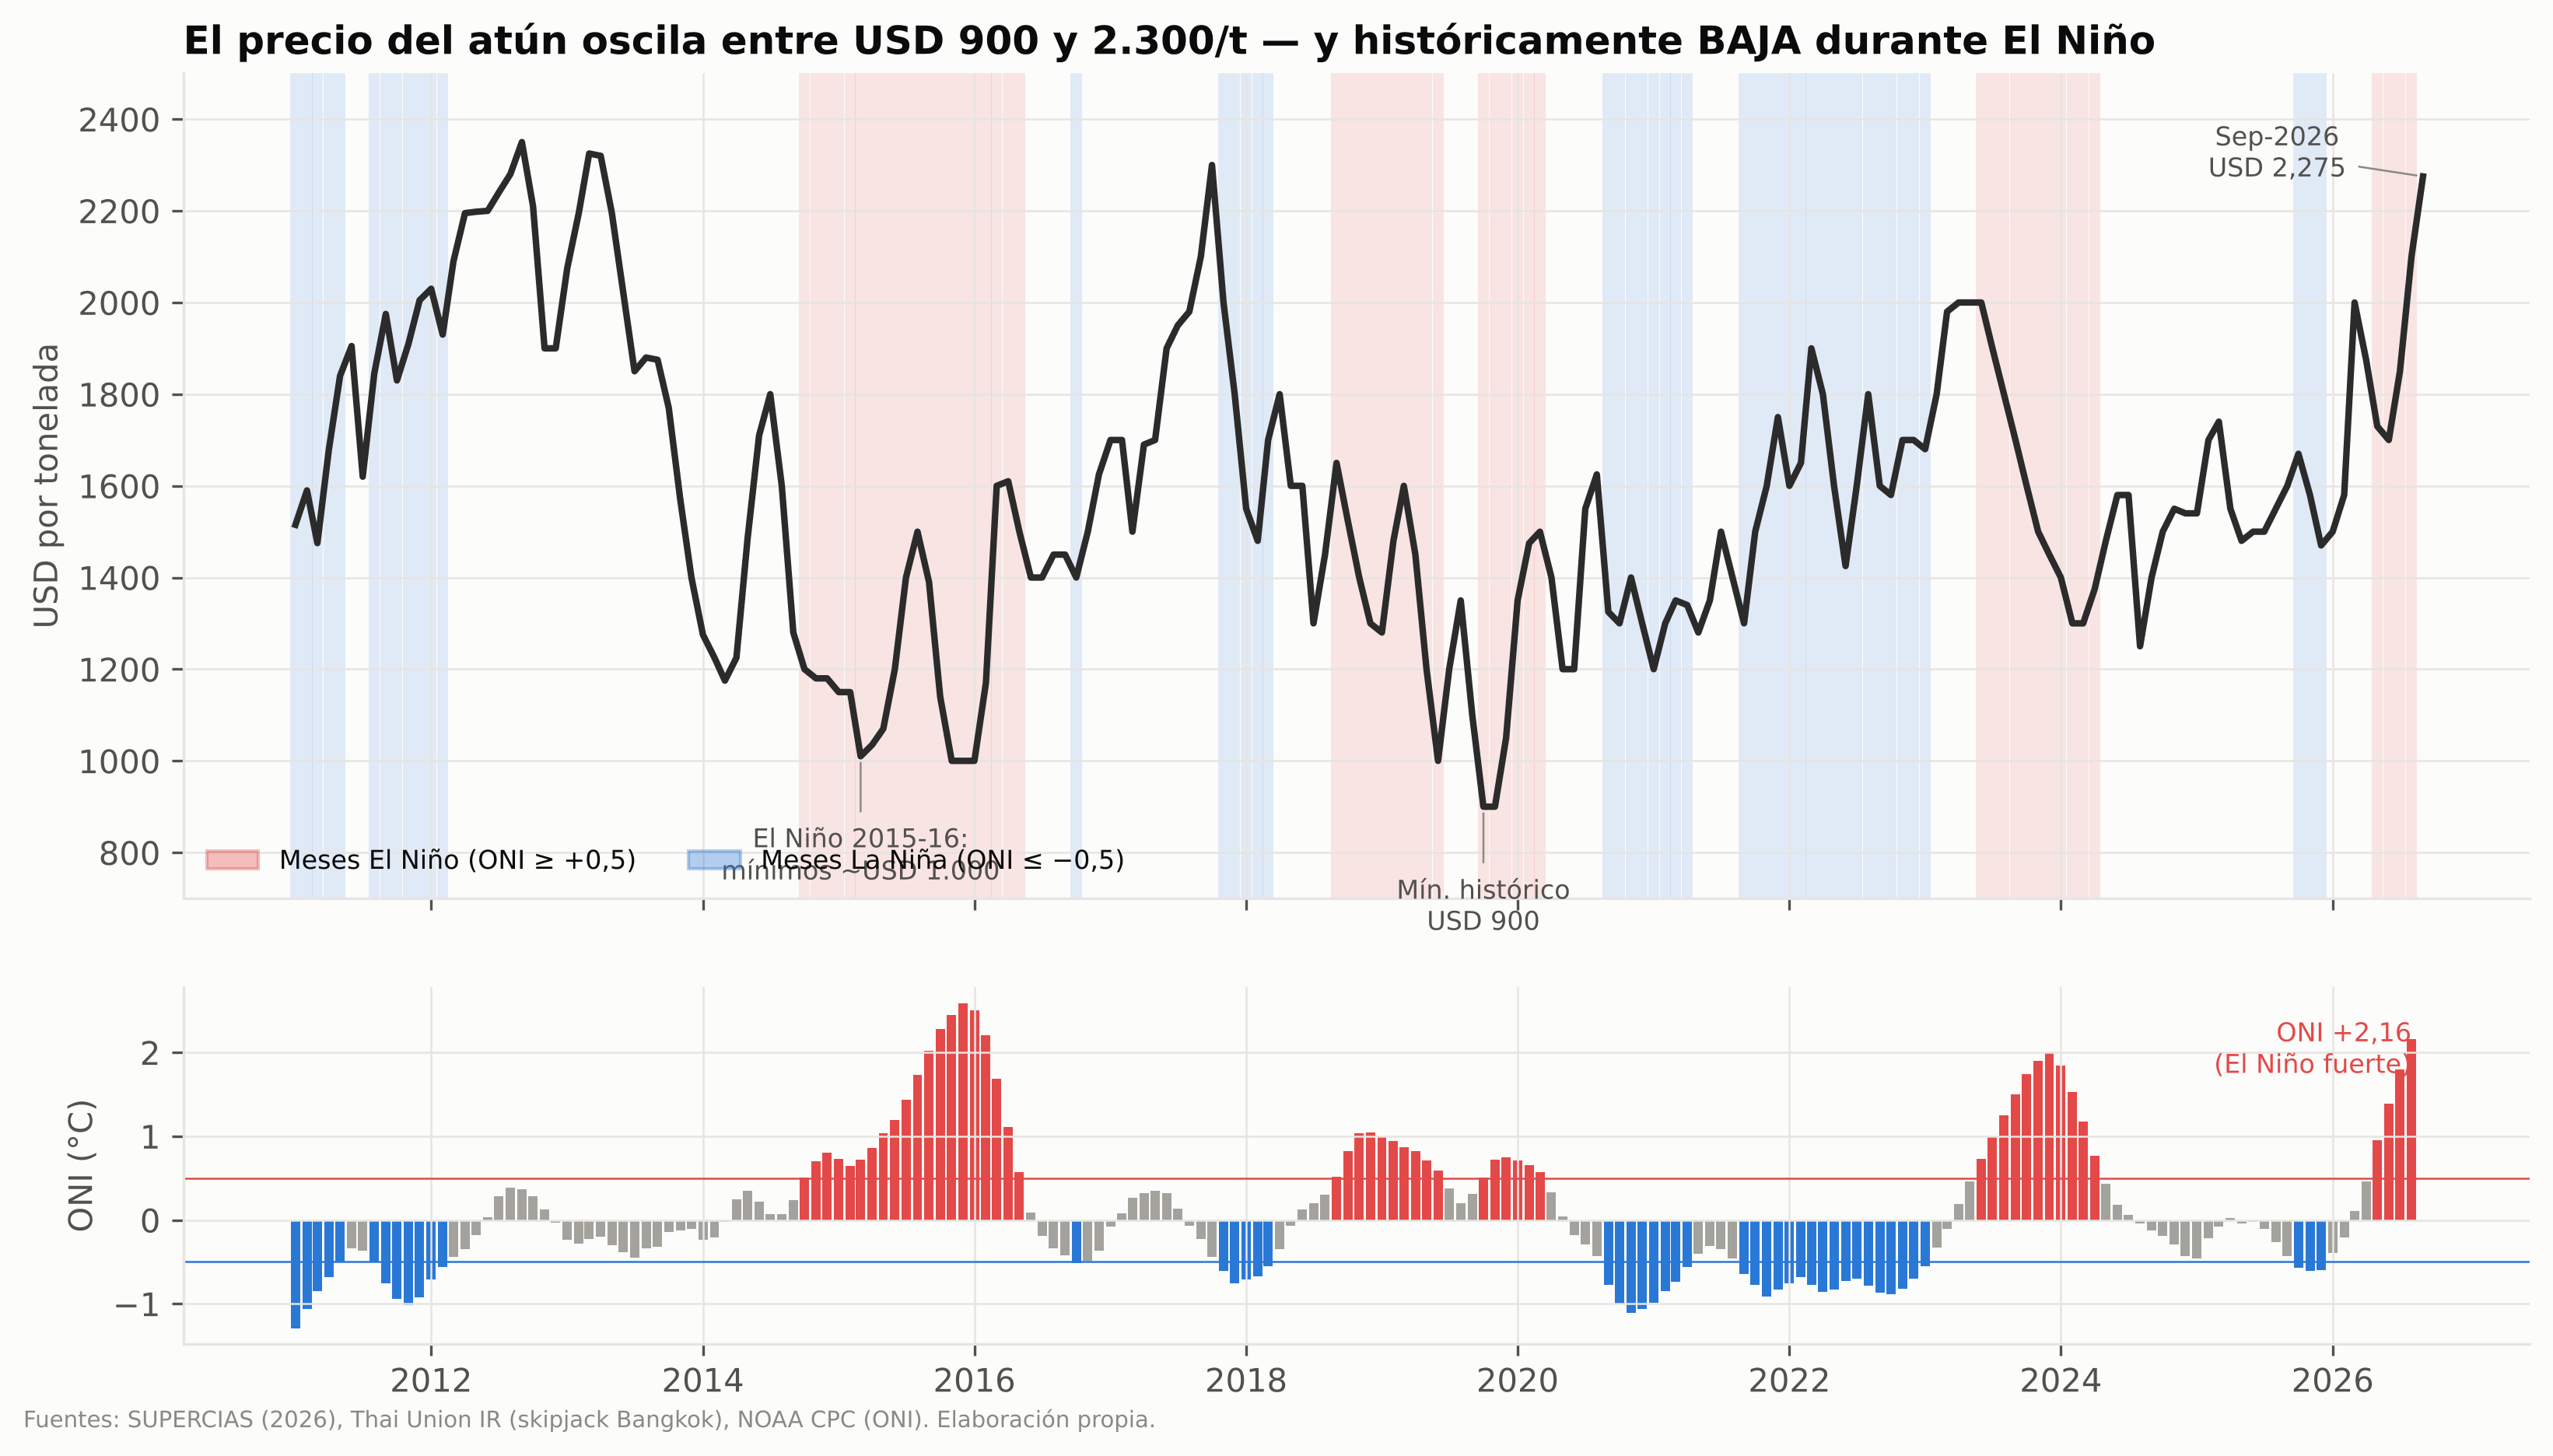

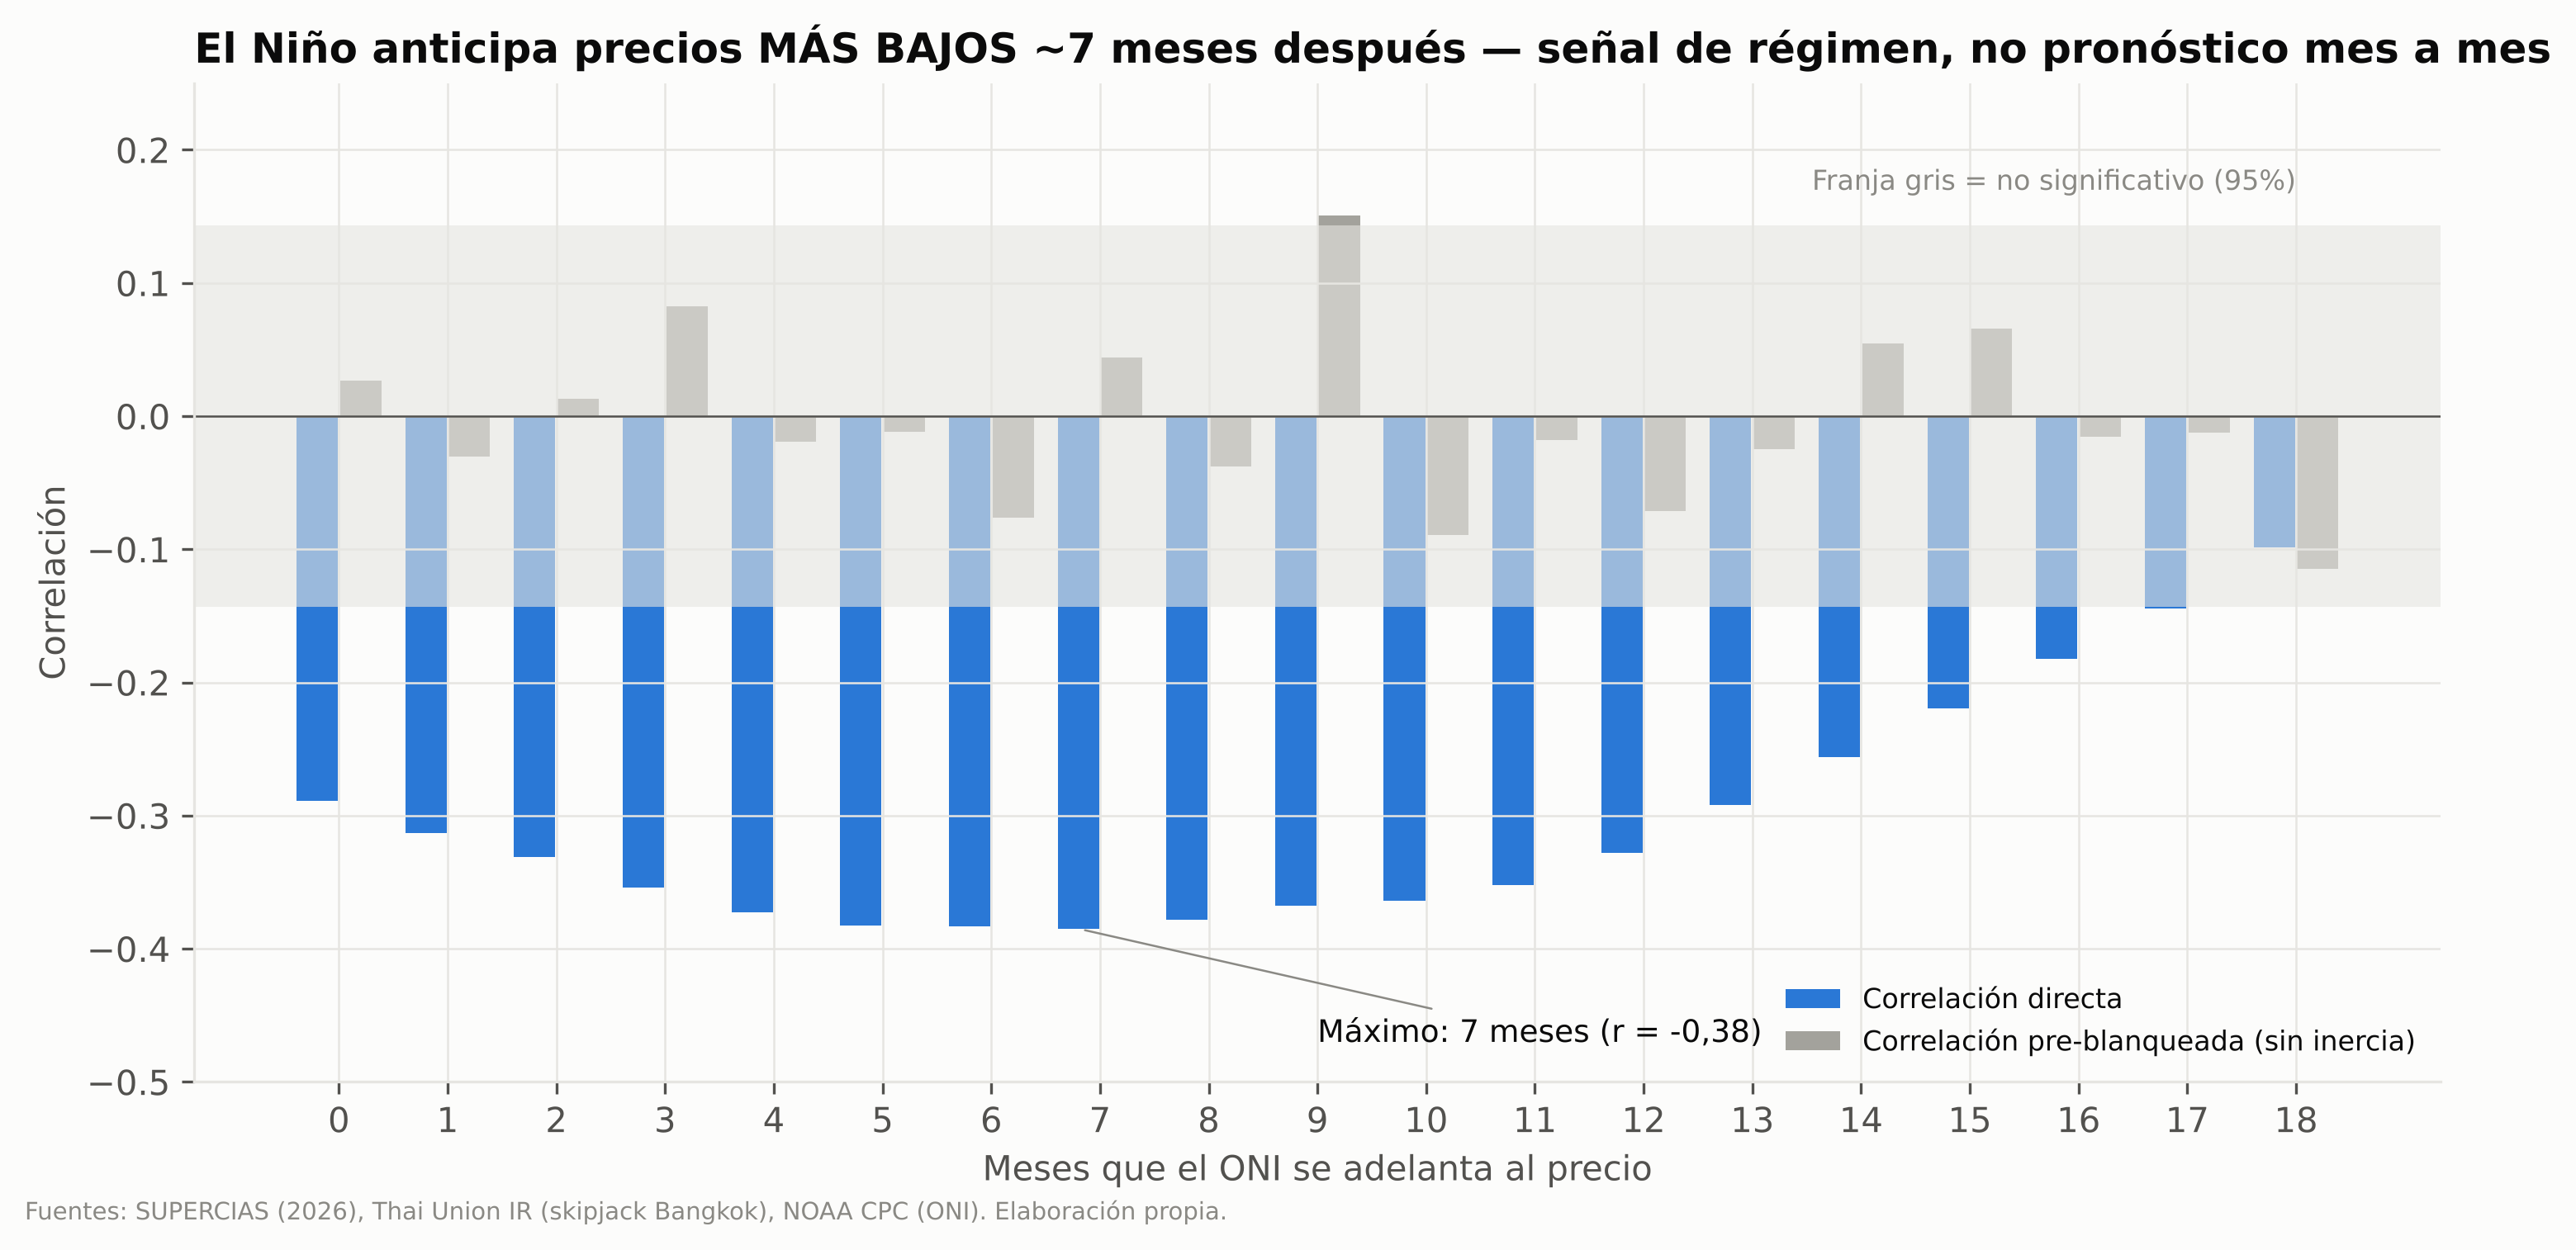

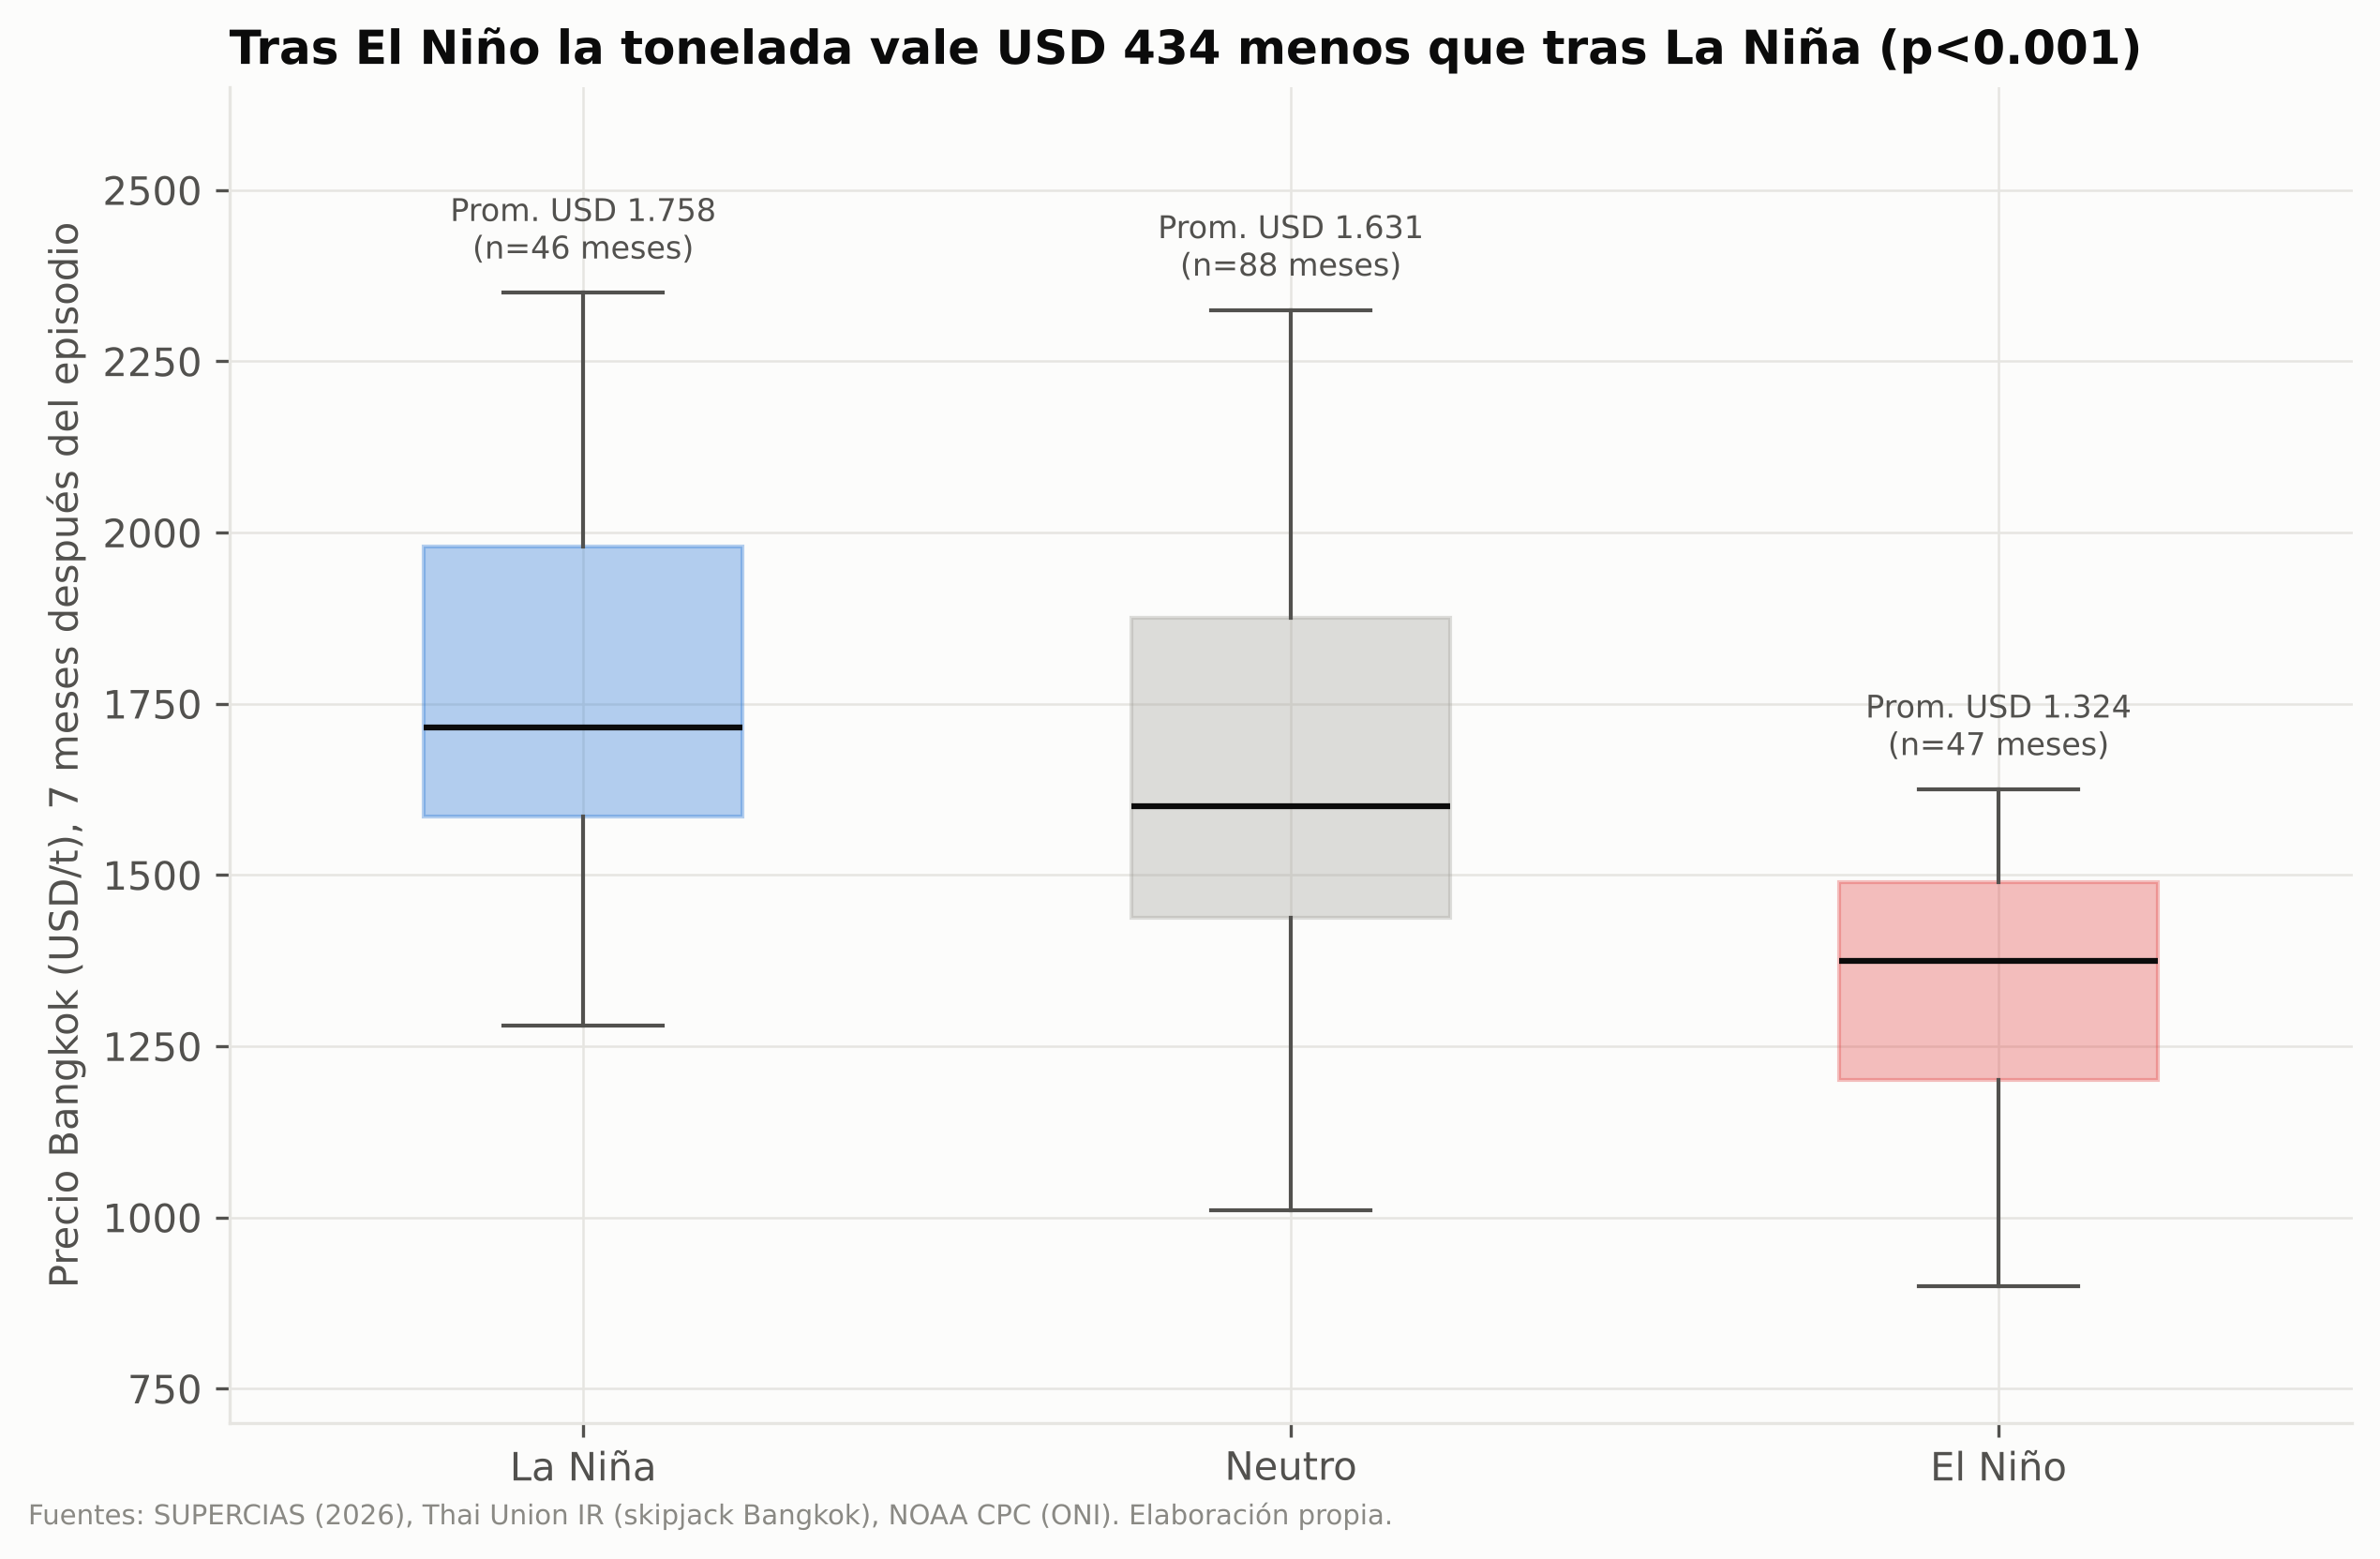

In [6]:
display(Image('../outputs/figures/fig1_precio_bangkok_enso.png', width=900))
display(Image('../outputs/figures/fig4_ccf_oni_precio.png', width=900))
display(Image('../outputs/figures/fig5_boxplot_precio_episodio_enso.png', width=700))

### Lectura
- **H2a — RECHAZADA (signo opuesto).** El Niño se asocia con precios Bangkok **más bajos**: ≈ −USD 434/t frente a La Niña a 7 meses (IC95 HAC −667 a −201; p<0,001).
  Es coherente con Lehodey et al. (1997): El Niño **redistribuye** el barrilete hacia el este y mantiene la oferta. La escasez que supone el protocolo no aparece en los datos.
- **H2c — rezago ~7 meses** (CCF máxima en valor absoluto, r ≈ −0,39). Advertencia: tras pre-blanquear, la correlación desaparece casi por completo, y **Granger no es significativo** (p mín ≈ 0,17).
  El ONI marca el **régimen** de precios de los meses siguientes, pero no mejora el pronóstico mes a mes una vez considerada la inercia del precio.
- **H2b — no linealidad parcial.** El término cuadrático es significativo con rezagos ≥ 10–12 meses (R² sube de ~0,12 a ~0,22). El precio mínimo se da con ONI ≈ +1 °C y repunta en los extremos, en línea con Ormaza-González et al. (2016).
- **2026 es una anomalía:** con ONI +2,16 el precio está en USD 2.275/t, por encima del intervalo de predicción del modelo. Hay que vigilar si el patrón histórico se reafirma (caída) o si dominan otros factores (Hou et al., 2022: no estacionariedad).